# Analysis of Trained SUMO Model Results

This notebook evaluates a trained Multi-Agent PPO model on the SUMO traffic simulation.  
It runs multiple episodes to collect statistics on rewards, queue lengths, waiting times, and throughput.

In [4]:
import os
import sys
from pathlib import Path
from warnings import filterwarnings


filterwarnings("ignore", category=DeprecationWarning)
filterwarnings("ignore", category=FutureWarning)
filterwarnings("ignore", category=UserWarning)

# Add project root to path for imports
PROJECT_ROOT = Path(os.path.abspath('')).parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Add SUMO tools to path
if 'SUMO_HOME' in os.environ:
    tools = os.path.join(os.environ['SUMO_HOME'], 'tools')
    if tools not in sys.path:
        sys.path.append(tools)
else:
    sys.path.append("/usr/share/sumo/tools") # Fallback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import traci
import yaml
from stable_baselines3 import PPO
from tqdm.notebook import tqdm

from agents.train_multi_agent_ppo import make_env

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## Configuration

In [5]:
TARGET_MODEL = 'multi_agent_ppo'
MODEL_PATH = PROJECT_ROOT / 'models' / TARGET_MODEL / 'final_model.zip'
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'multi_agent_ppo.yaml'
# Using simple4 intersection
SUMO_CFG_PATH = PROJECT_ROOT / 'sim' / 'intersections' / 'simple4' / 'simple4.sumocfg'

N_EPISODES = 5
GUI = False  # Set to True to watch simulation (slower)

print(f"Loading model from: {MODEL_PATH}")

Loading model from: /mnt/shared/dev/traffic-zero/models/multi_agent_ppo/final_model.zip


## Load Model and Config

In [6]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")

model = PPO.load(MODEL_PATH)

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

# Ensure correct SUMO config path if relative
if not os.path.isabs(SUMO_CFG_PATH):
    # Attempt to find it relative to project root if not absolute
    POSSIBLE_PATH = PROJECT_ROOT / 'sim' / 'intersections' / 'simple4' / 'simple4.sumocfg'
    if POSSIBLE_PATH.exists():
        SUMO_CFG_PATH = POSSIBLE_PATH

print(f"SUMO Config: {SUMO_CFG_PATH}")

SUMO Config: /mnt/shared/dev/traffic-zero/sim/intersections/simple4/simple4.sumocfg


## Run Evaluation Loop

In [7]:
episode_metrics = []
step_metrics = []

print(f"Running {N_EPISODES} episodes...")

for ep in tqdm(range(N_EPISODES), desc="Episodes"):
    try:
        env = make_env(str(SUMO_CFG_PATH), config, gui=GUI)
        obs, _ = env.reset()
        
        done = False
        total_reward = 0
        steps = 0
        
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            total_reward += reward
            steps += 1
            
            # Collect Step Metrics via Traci
            try:
                vehs = traci.vehicle.getIDList()
                n_vehicles = len(vehs)
                total_waiting_time = sum(traci.vehicle.getWaitingTime(v) for v in vehs)
                halting_count = sum(1 for v in vehs if traci.vehicle.getSpeed(v) < 0.1)
                
                step_metrics.append({
                    'episode': ep,
                    'step': steps,
                    'reward': reward,
                    'n_vehicles': n_vehicles,
                    'total_waiting_time': total_waiting_time,
                    'halting_count': halting_count
                })
            except Exception as e:
                pass # Traci might be closed if done just happened
                
        env.close()
        
        episode_metrics.append({
            'episode': ep,
            'total_reward': total_reward,
            'steps': steps,
            'avg_waiting_time': np.mean([m['total_waiting_time'] for m in step_metrics if m['episode'] == ep]),
            'avg_queue': np.mean([m['halting_count'] for m in step_metrics if m['episode'] == ep])
        })
        
    except Exception as e:
        print(f"Episode {ep} failed: {e}")
        try:
            env.close()
        except:
            pass

df_steps = pd.DataFrame(step_metrics)
df_eps = pd.DataFrame(episode_metrics)

print("Evaluation complete.")

Running 5 episodes...


Episodes:   0%|          | 0/5 [00:00<?, ?it/s]

 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Evaluation complete.


## Results Analysis

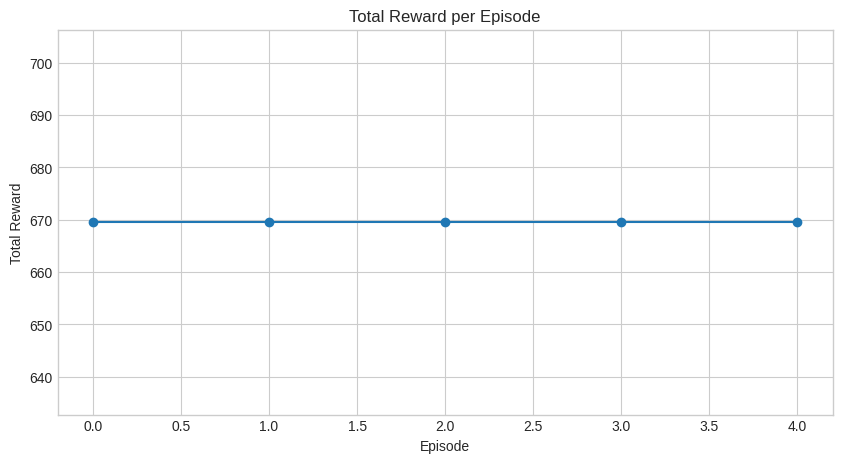

In [8]:
if not df_eps.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(df_eps['episode'], df_eps['total_reward'], marker='o')
    plt.title('Total Reward per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()
else:
    print("No episode data collected.")

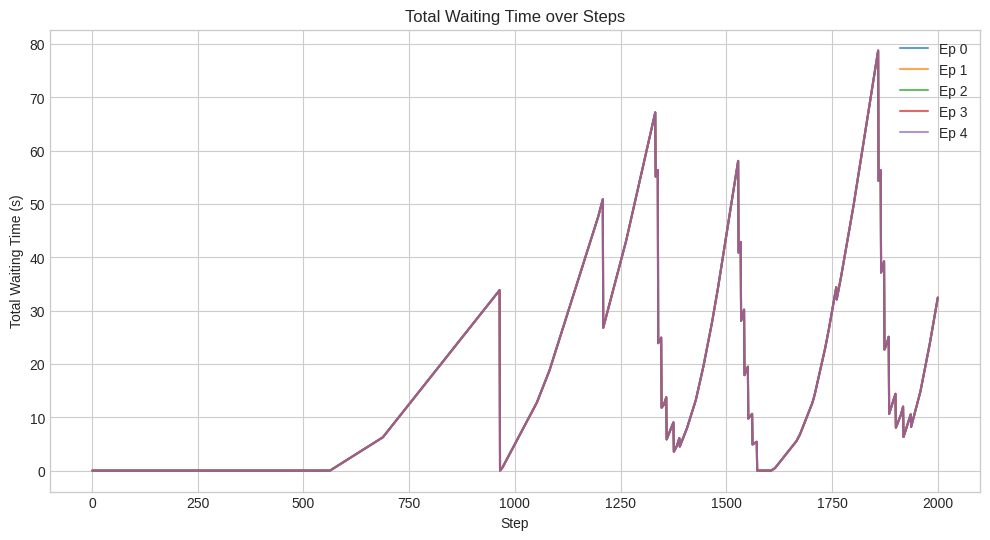

In [9]:
if not df_steps.empty:
    plt.figure(figsize=(12, 6))
    for ep in df_steps['episode'].unique():
        subset = df_steps[df_steps['episode'] == ep]
        plt.plot(subset['step'], subset['total_waiting_time'], label=f'Ep {ep}', alpha=0.7)

    plt.title('Total Waiting Time over Steps')
    plt.xlabel('Step')
    plt.ylabel('Total Waiting Time (s)')
    plt.legend()
    plt.show()

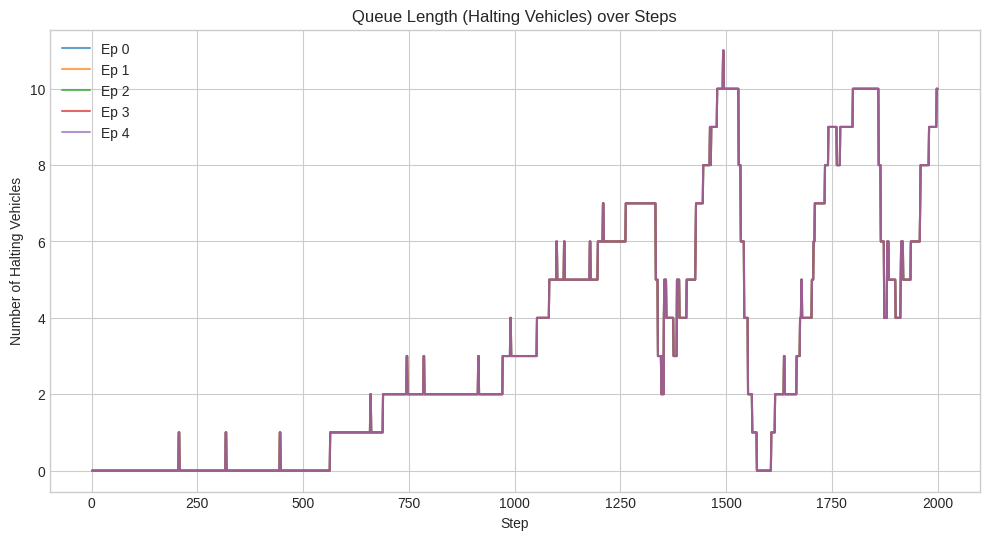

In [10]:
if not df_steps.empty:
    plt.figure(figsize=(12, 6))
    for ep in df_steps['episode'].unique():
        subset = df_steps[df_steps['episode'] == ep]
        plt.plot(subset['step'], subset['halting_count'], label=f'Ep {ep}', alpha=0.7)

    plt.title('Queue Length (Halting Vehicles) over Steps')
    plt.xlabel('Step')
    plt.ylabel('Number of Halting Vehicles')
    plt.legend()
    plt.show()

In [11]:
if not df_eps.empty:
    print("Summary Statistics:")
    print(f"Average Reward: {df_eps['total_reward'].mean():.2f} +/- {df_eps['total_reward'].std():.2f}")
    print(f"Average Waiting Time (Total per Step): {df_eps['avg_waiting_time'].mean():.2f}")
    print(f"Average Queue Length (Vehicles): {df_eps['avg_queue'].mean():.2f}")
else:
    print("No stats available.")

Summary Statistics:
Average Reward: 669.55 +/- 0.00
Average Waiting Time (Total per Step): 16.20
Average Queue Length (Vehicles): 3.26


## Naive Controller Comparison

Compare the PPO agent against a fixed-time controller that cycles phases every 30 seconds.

In [12]:
class NaiveController:
    """
    Fixed-time traffic controller that cycles through phases with a fixed duration.
    
    Each phase is held for cycle_time seconds (default 30s) before switching to the next.
    This serves as a baseline comparison for the trained PPO agent.
    """
    def __init__(self, num_agents, num_phases=4, cycle_time=30, min_duration=10, duration_step=10):
        self.num_agents = num_agents
        self.num_phases = num_phases
        self.current_phase = 0
        # Calculate duration index for action space (cycle_time maps to duration_idx)
        # duration_idx=2 corresponds to 30s when min_duration=10 and duration_step=10
        self.duration_idx = int((cycle_time - min_duration) / duration_step)

    def predict(self, obs, deterministic=True):
        """Return action that sets current phase with fixed duration, then advance phase."""
        phase = self.current_phase
        # Cycle to next phase for the next call
        self.current_phase = (self.current_phase + 1) % self.num_phases
        # Action format: [phase, duration_idx] per agent, flattened
        action_per_agent = [phase, self.duration_idx]
        return np.array(action_per_agent * self.num_agents), None

In [13]:
naive_step_metrics = []
naive_episode_metrics = []

print(f"Running Naive Controller for {N_EPISODES} episodes...")

for ep in tqdm(range(N_EPISODES), desc="Naive Episodes"):
    try:
        env = make_env(str(SUMO_CFG_PATH), config, gui=GUI)
        obs, _ = env.reset()
        
        # Get number of agents from the unwrapped environment (TimeLimit doesn't expose agent_ids directly)
        num_agents = len(env.unwrapped.agent_ids)
        
        # Initialize naive controller with fixed 30s phase cycling
        naive_model = NaiveController(
            num_agents=num_agents,
            num_phases=config['action_config'].get('num_phases', 4),
            min_duration=config['action_config'].get('min_duration', 10),
            duration_step=config['action_config'].get('duration_step', 10)
        )
        
        done = False
        total_reward = 0
        steps = 0
        
        while not done:
            action, _ = naive_model.predict(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            total_reward += reward
            steps += 1
            
            # Collect Step Metrics
            try:
                vehs = traci.vehicle.getIDList()
                total_waiting_time = sum(traci.vehicle.getWaitingTime(v) for v in vehs)
                halting_count = sum(1 for v in vehs if traci.vehicle.getSpeed(v) < 0.1)
                
                naive_step_metrics.append({
                    'episode': ep,
                    'step': steps,
                    'total_waiting_time': total_waiting_time,
                    'halting_count': halting_count
                })
            except:
                pass
                
        env.close()
        
        naive_episode_metrics.append({
            'episode': ep,
            'total_reward': total_reward,
            'avg_waiting_time': np.mean([m['total_waiting_time'] for m in naive_step_metrics if m['episode'] == ep]),
            'avg_queue': np.mean([m['halting_count'] for m in naive_step_metrics if m['episode'] == ep])
        })
        
    except Exception as e:
        print(f"Naive Episode {ep} failed: {e}")
        try: env.close() 
        except: pass

df_naive_eps = pd.DataFrame(naive_episode_metrics)
print("Naive evaluation complete.")

Running Naive Controller for 5 episodes...


Naive Episodes:   0%|          | 0/5 [00:00<?, ?it/s]

 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Naive evaluation complete.


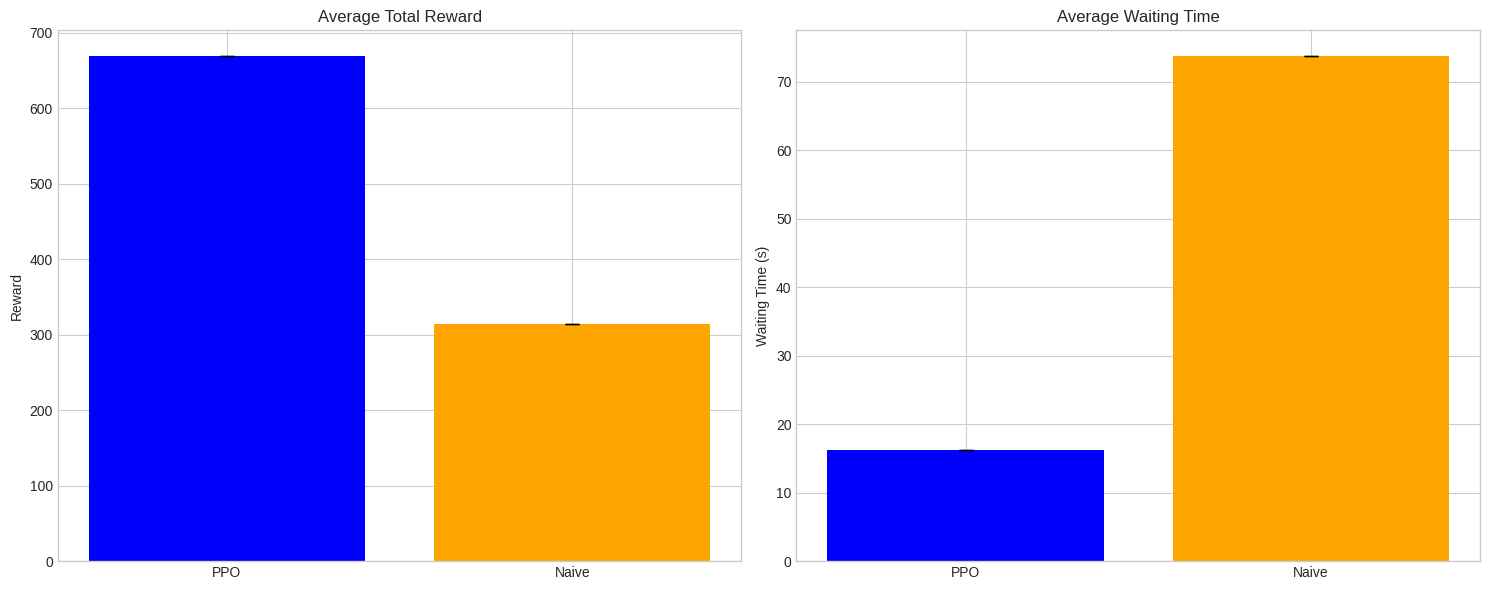

             Metric    PPO Mean  Naive Mean
0      Total Reward  669.549017  313.471957
1  Avg Waiting Time   16.196700   73.817225
2  Avg Queue Length    3.265000    6.060500


In [14]:
if not df_eps.empty and not df_naive_eps.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Total Reward Comparison
    axes[0].bar(['PPO', 'Naive'], [df_eps['total_reward'].mean(), df_naive_eps['total_reward'].mean()], 
                yerr=[df_eps['total_reward'].std(), df_naive_eps['total_reward'].std()], capsize=5, color=['blue', 'orange'])
    axes[0].set_title('Average Total Reward')
    axes[0].set_ylabel('Reward')
    
    # Waiting Time Comparison
    axes[1].bar(['PPO', 'Naive'], [df_eps['avg_waiting_time'].mean(), df_naive_eps['avg_waiting_time'].mean()], 
                yerr=[df_eps['avg_waiting_time'].std(), df_naive_eps['avg_waiting_time'].std()], capsize=5, color=['blue', 'orange'])
    axes[1].set_title('Average Waiting Time')
    axes[1].set_ylabel('Waiting Time (s)')
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison table
    summary = pd.DataFrame({
        'Metric': ['Total Reward', 'Avg Waiting Time', 'Avg Queue Length'],
        'PPO Mean': [df_eps['total_reward'].mean(), df_eps['avg_waiting_time'].mean(), df_eps['avg_queue'].mean()],
        'Naive Mean': [df_naive_eps['total_reward'].mean(), df_naive_eps['avg_waiting_time'].mean(), df_naive_eps['avg_queue'].mean()]
    })
    print(summary)
else:
    print("Insufficient data for comparison.")